In [24]:
print('Hello World')

Hello World


In [98]:
#!pip install openpyxl
#!mamba install pandas
#!mamba install scikit-learn
#!mamba install seaborn
#!mamba install warnings
!mamba install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
from sklearn.cluster import KMeans
#pd.options.display.float_format = 'Worldwide Box Office':'{:,.2f}'.format
pd.options.display.float_format = '{:20,.2f}'.format
df = pd.read_excel('Data Mining Movie Set.xlsx')

#print(df.head())
#df.info()
df.describe()
#df.nunique()
#df.isnull().sum()
#df = df.dropna()
#df.isnull().sum()

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 7.589 seconds
All requested packages already installed.


,Worldwide Box Office,Critical Response,Audience Response,Year of Release
count,413.00,412.00,415.00,416.00
mean,"519,586,486.34",0.83,0.87,"1,999.04"
std,"506,662,050.96",0.17,0.12,23.97
min,399.00,0.18,0.41,"1,921.00"
25%,"32,267,129.00",0.77,0.84,"1,989.75"
50%,"482,352,390.00",0.90,0.91,"2,008.00"
75%,"824,171,374.00",0.94,0.94,"2,016.00"
max,"2,923,710,708.00",1.00,1.00,"2,025.00"


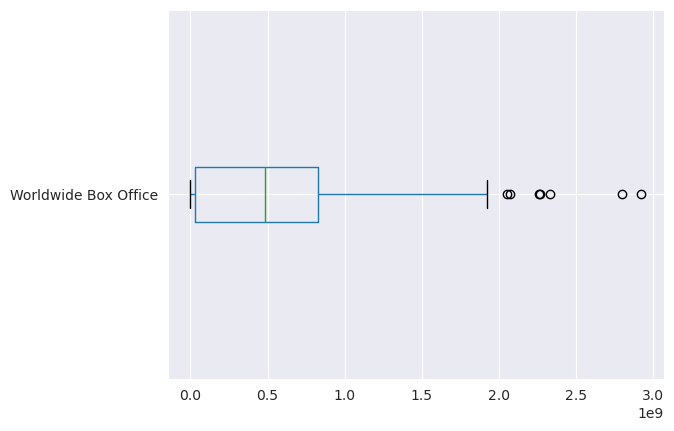

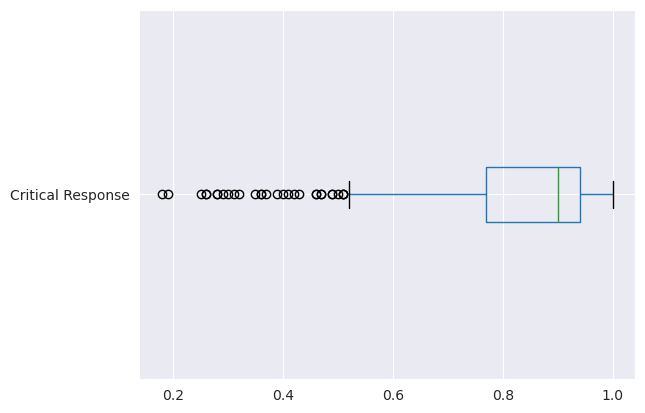

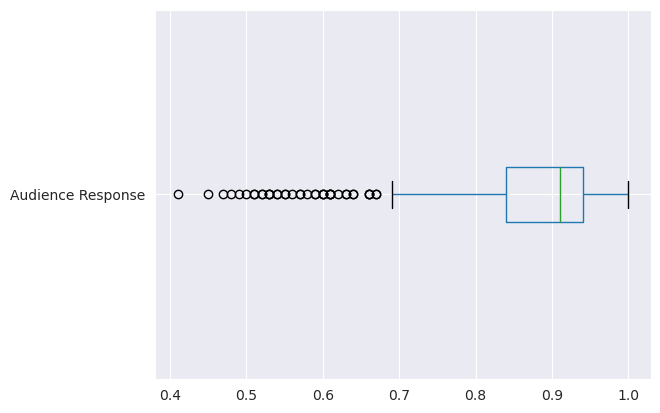

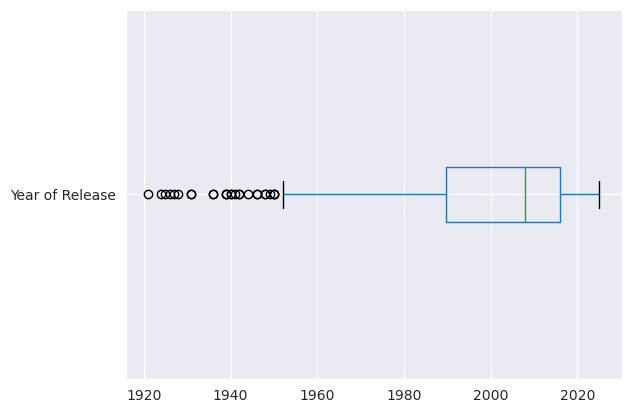

In [117]:
df.describe()

#fig = plt.figure(figsize = (10, 10))

df.boxplot(column=['Worldwide Box Office'],vert=False)
plt.show()
df.boxplot(column=['Critical Response'],vert=False)
plt.show()
df.boxplot(column=['Audience Response'],vert=False)
plt.show()
df.boxplot(column=['Year of Release'],vert=False)
plt.show()

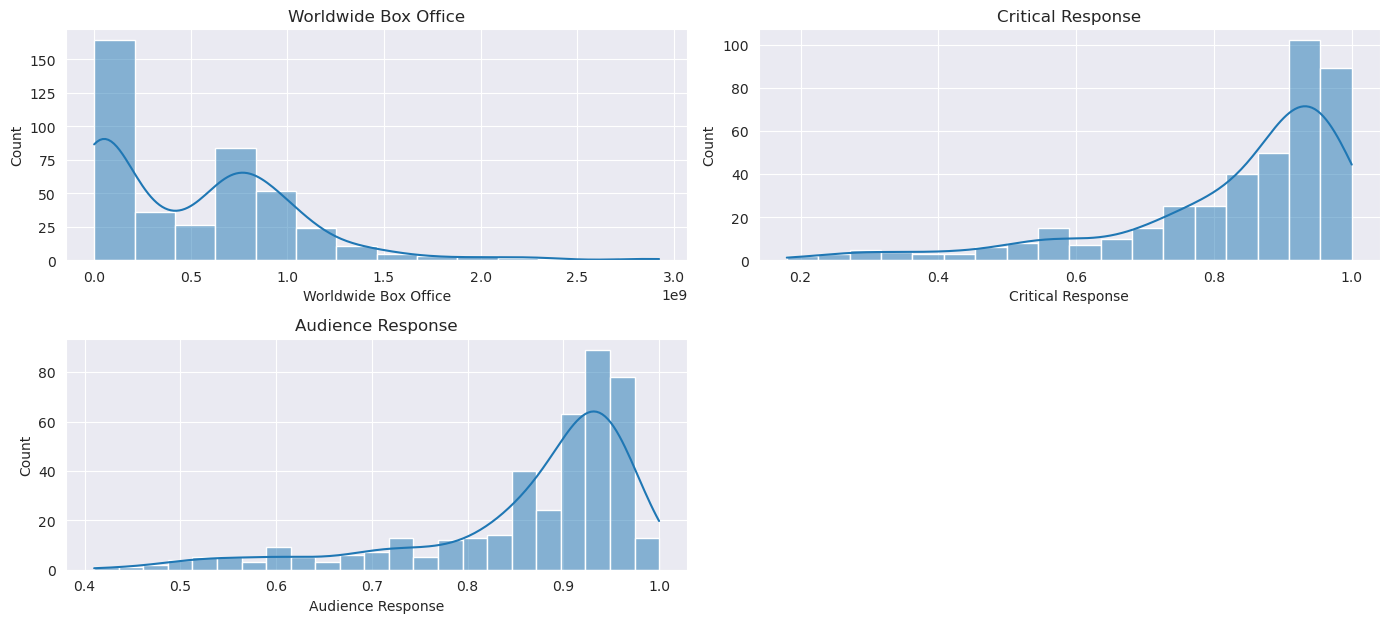

In [119]:
sns.set_style("darkgrid")

float_columns = df.select_dtypes(include=["float64"]).columns
#numerical_columns = df.select_dtypes(include=["int64"]).columns
plt.figure(figsize=(14, len(float_columns) * 3))
for idx, feature in enumerate(float_columns, 1):
    plt.subplot(len(float_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature}")

plt.tight_layout()
plt.show()

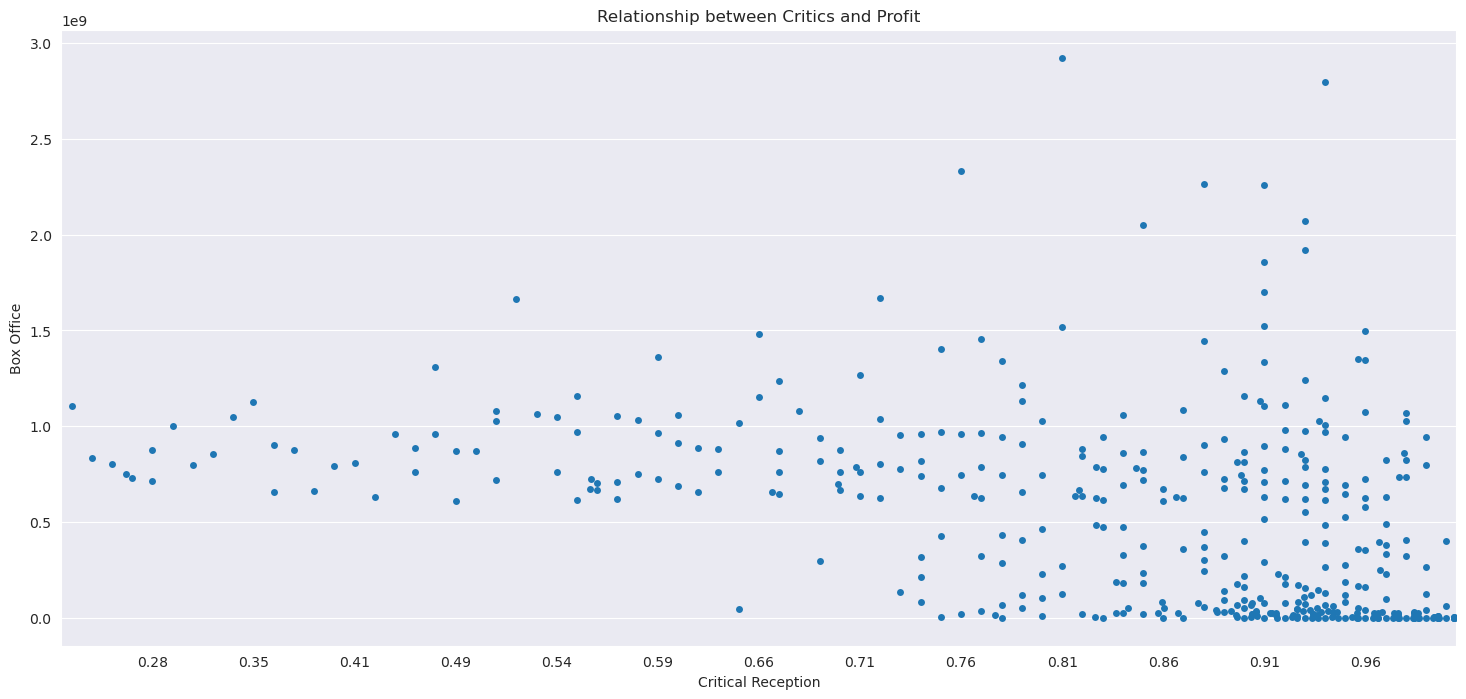

In [152]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
#This one part was kicking my ass
plt.title('Relationship between Critics and Profit')
plt.xlabel('Critical Reception')
plt.ylabel('Box Office')
plt.show()

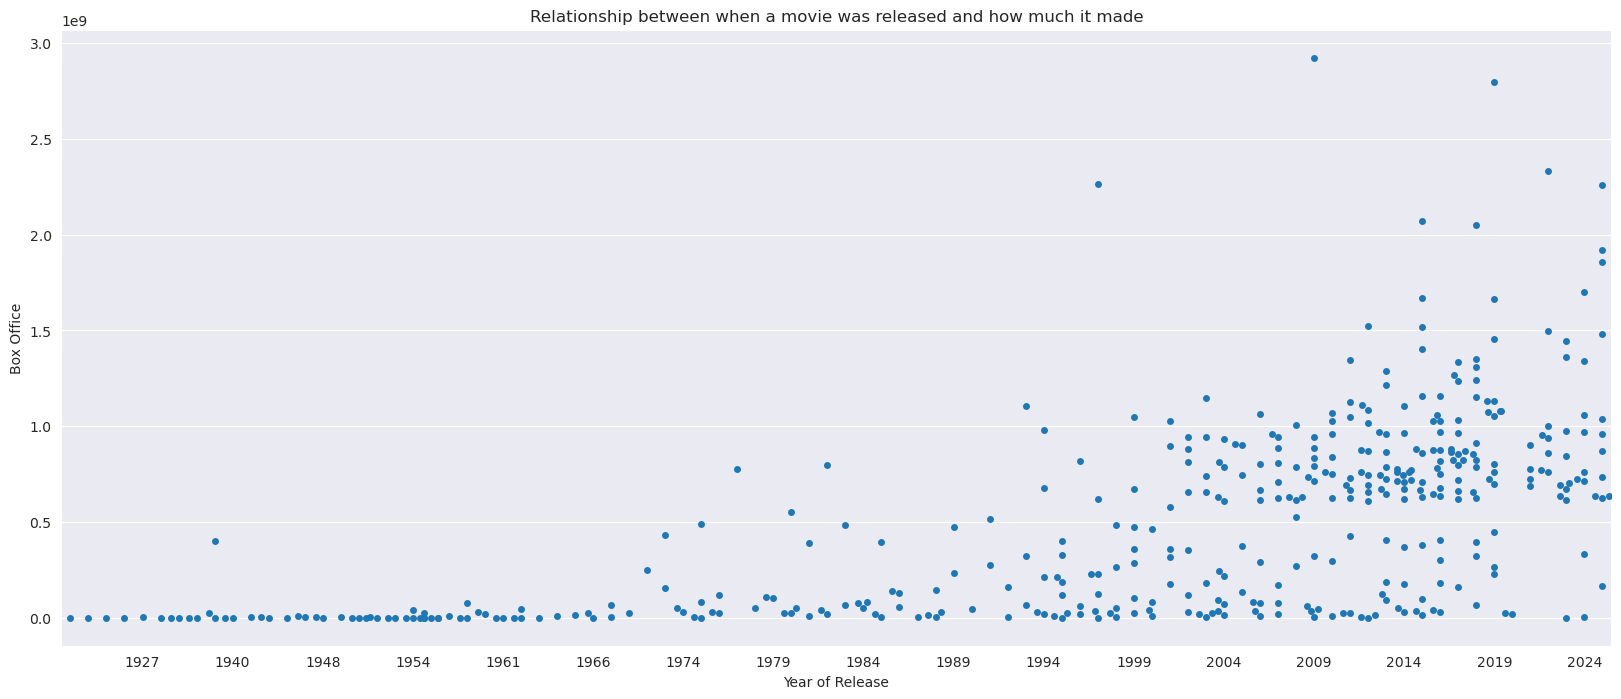

In [155]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Year of Release", y="Worldwide Box Office", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Relationship between when a movie was released and how much it made')
plt.xlabel('Year of Release')
plt.ylabel('Box Office')
plt.show()

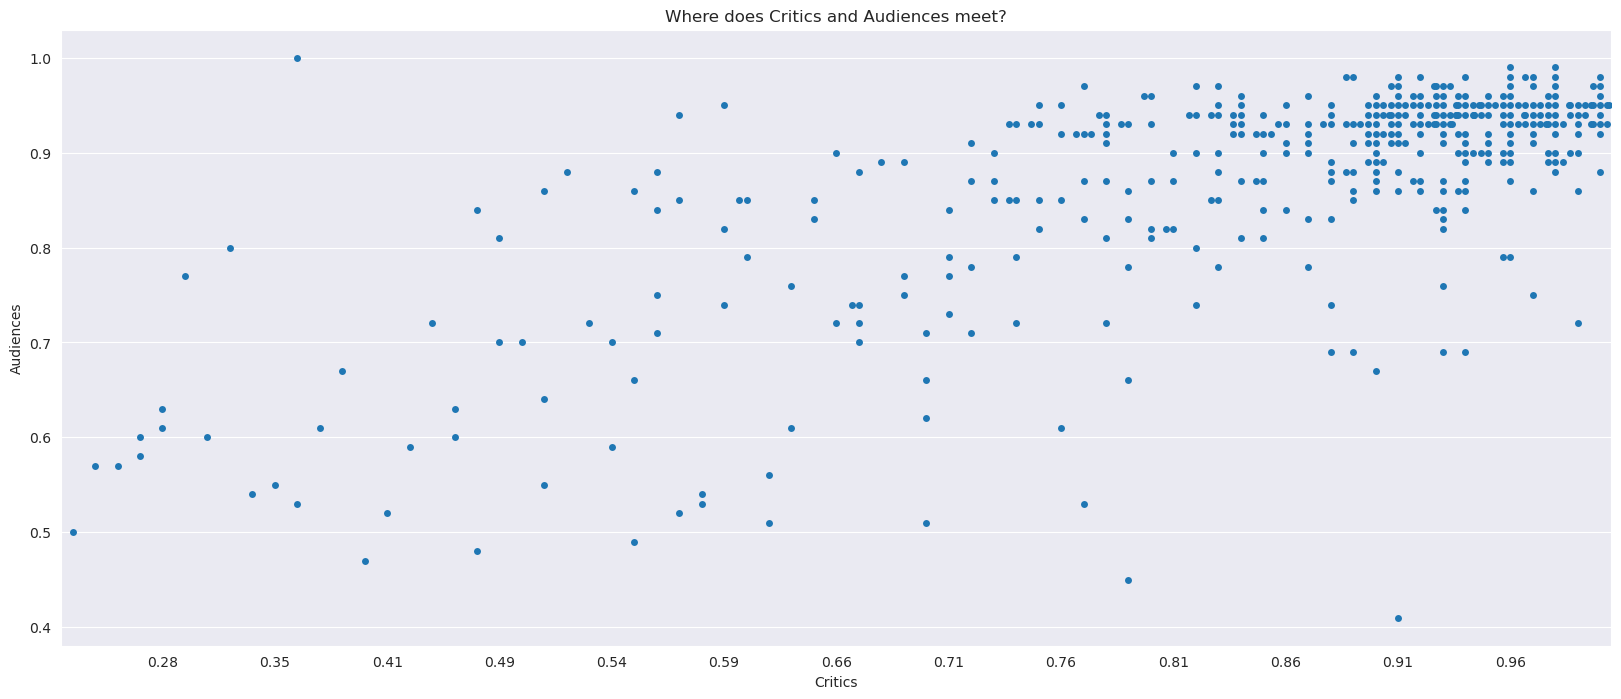

In [156]:
plt.figure(figsize=(20, 8))

dm = sns.swarmplot(x="Critical Response", y="Audience Response", data=df, dodge=True)
ticks = dm.get_xticks()
dm.set_xticks(ticks[4::5])
plt.title('Where does Critics and Audiences meet?')
plt.xlabel('Critics')
plt.ylabel('Audiences')
plt.show()

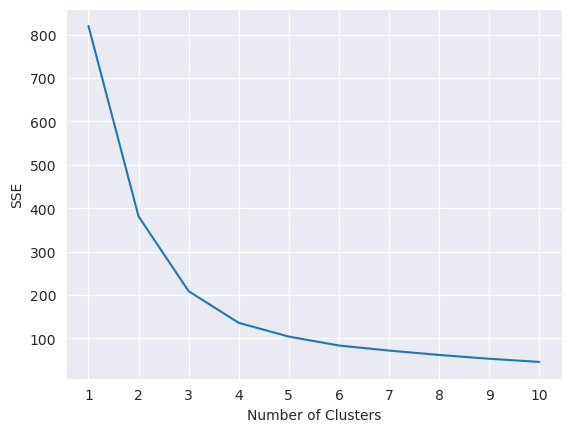

                                          Film Name  Worldwide Box Office  \
10                                 Django Unchained             21,900.00   
24                                        12th Fail            138,288.00   
37                                         La Haine            764,368.00   
38                               Children of Heaven            933,933.00   
42                               Memories of Murder          1,211,583.00   
..                                              ...                   ...   
210                                          WALL·E        527,404,782.00   
211  Star Wars: Episode V - The Empire Strikes Back        550,016,086.00   
212                                  Monsters, Inc.        579,773,055.00   
218                   The Lost World: Jurassic Park        618,638,999.00   
290              Star Wars: Episode IV - A New Hope        775,398,507.00   

       Critical Response    Audience Response  Year of Release  cluster  
1

In [138]:
from sklearn.preprocessing import StandardScaler
df = df.dropna()
data = df.iloc[: , [1,4]].values
scaled_df = StandardScaler().fit_transform(data)
#print(scaled_df[:5])

kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

kmeans = KMeans(init="random", n_clusters=3, n_init=10, random_state=1)

#fit k-means algorithm to data
kmeans.fit(scaled_df)

#view cluster assignments for each observation
kmeans.labels_

df['cluster'] = kmeans.labels_

#view updated DataFrame
print(df[df['cluster'] == 0])
print(df[df['cluster'] == 1])
print(df[df['cluster'] == 2])